# Ejercicio 19

El generador de Fibonacci con retardo es un algoritmo para generar n ́umeros pseudoaleatorios basado en la recurrencia de Fibonacci generalizada. esta dado por la siguiente expresion



$X_n = (X_{n-j}\ast X_{n-k})mod(m)$


En donde:

- $X_n$ es el n-esimo numero de la secuencia
- j y k son los retardos(lags) con $j<k$
- $\ast$ es una operacion binaria
- m es el modulo (usualmente $2^{32}$) 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Primero vamos a generar una lista de p numeros aleatorios, este sera el array inicial que luego usaremos para fibonacci. Nos podemos ayudar con el generador de congruencia lineal que definimos en el ejercicio anterior!!

In [2]:
#definimos la funcion de generador de numeros pseudoaleatorios por el metodo de congruencia lineal

def generador_congruencia_lineal(a,c,M,X1,p): #
    numeros = []                     
    x = X1                           
    for i in range(p):               
        x = (a*x + c) % M            
        numeros.append(x)          
    return numeros                  


#definimos los parametros del generador  

a = 1664525
c = 1013904223
M = 2**32
X1 = 10
p = 1000

#generamos los numeros

numeros_generados = generador_congruencia_lineal(a,c,M,X1,p) #aca estamos definiendo una variable numeros_generados, que va a guardar el resultado de la funcion que definimos arriba, y le pasamos los parametros que necesita


Ahora procedemos a definir la funcion para generar los numeros pseudoaleatorios por el metodo de fibonacci

In [3]:
#definimos la funcion 

def generador_fibonacci(j, k, m, n, numeros_generados):
    # Verificamos que la lista inicial tenga al menos max(j, k) elementos
    if len(numeros_generados) < max(j, k): 
        raise ValueError("La lista inicial debe tener al menos max(j, k) elementos")

    numeros_generados_fibonacci = []

    # Generamos n nuevos valores usando la fórmula con retardo
    for i in range(max(j, k), max(j, k) + n): #empezamos en max(j,k) porque los primeros valores ya los tenemos en la lista inicial
        X = (numeros_generados[i - j] + numeros_generados[i - k]) % m #aplicamos la formula recursiva
        numeros_generados.append(X)  # extendemos la lista original con el nuevo valor generado
        numeros_generados_fibonacci.append(X / m)  # normalizamos

    return numeros_generados_fibonacci



#ahora necesitamos definir los parametros que va a necesitar la funcion
j = 24
k= 55
m = 2**32
n = 10000
#ahora vamos a generar los numeros

numeros_fibonacci = generador_fibonacci(j,k,m,n,numeros_generados) #aca estamos definiendo una variable numeros_generados_fibonaci, que va a guardar el resultado de la funcion que definimos arriba, y le pasamos los parametros que necesita

print(numeros_fibonacci) #imprimimos los numeros generados por el metodo de fibonacci
print(len(numeros_fibonacci)) #imprimimos la cantidad de numeros generados por el metodo de fibonacci

[0.8133183445315808, 0.1895673752296716, 0.10739011480472982, 0.002981288591399789, 0.9015285454224795, 0.2742052983958274, 0.04644826031289995, 0.7626332754734904, 0.6249934572260827, 0.7065251909662038, 0.31562896608375013, 0.7769064998719841, 0.7638353600632399, 0.5248452101368457, 0.44553897879086435, 0.24080780916847289, 0.09069209801964462, 0.7365920946467668, 0.42847785516642034, 0.5740068315062672, 0.19334891508333385, 0.5750150319654495, 0.3682182354386896, 0.9304795304778963, 0.9126046660821885, 0.7539464004803449, 0.10439549176953733, 0.37807363481260836, 0.48912240262143314, 0.939359386684373, 0.6552567516919225, 0.7167459430638701, 0.013014334021136165, 0.1564724773634225, 0.822519296547398, 0.404221503296867, 0.2699111632537097, 0.3511508267838508, 0.8020883349236101, 0.5578246677760035, 0.5772657978814095, 0.824354498879984, 0.14438415109179914, 0.5012320226524025, 0.7046414359938353, 0.7583835844416171, 0.9080286284442991, 0.8248971926514059, 0.47173402714543045, 0.5536

Ahora, queremos calcular la media y la varianza muestral de nuestros numeros generados:

In [7]:
datos = np.array(numeros_fibonacci) #convertimos la lista en un array
media = np.mean(datos) #calculamos la media
varianza = np.var(datos) #calculamos la varianza

print("Media:", media) #imprimimos la media
print("Varianza:", varianza) #imprimimos la varianza
print("Media teorica:", 0.5) #imprimimos la media teorica
print("Varianza teorica:", 1/12) #imprimimos la varianza teorica

Media: 0.4975344238470774
Varianza: 0.08334157961515636
Media teorica: 0.5
Varianza teorica: 0.08333333333333333


Nos interesa ahora ver como se distribuyen estos numeros generados en un histograma para estudiar su distribucion.

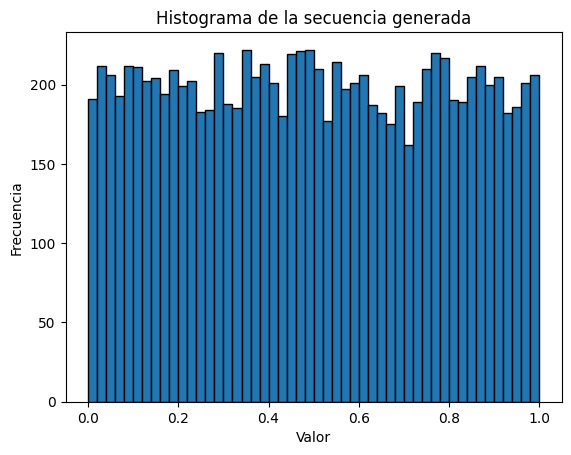

In [5]:
plt.hist(datos, bins=50, edgecolor='black')  # 50 intervalos, con bordes visibles
plt.title('Histograma de la secuencia generada')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()

Para terminar de definir que tan bueno es nuestro generador, podemos comparar con generadores de librerias conocidas como numpy.

Media numpy: 0.5008671361948546
Varianza numpy: 0.08352193282494466


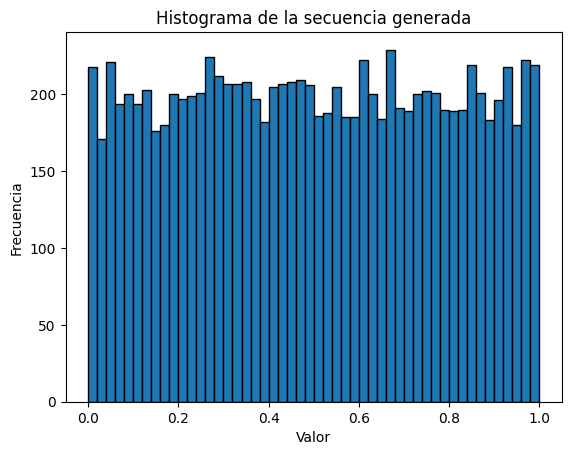

In [6]:
datos_numpy = np.random.random(10000) #generamos 10000 numeros aleatorios con numpy

media_numpy = np.mean(datos_numpy) #calculamos la media
varianza_numpy = np.var(datos_numpy) #calculamos la varianza    
print("Media numpy:", media_numpy) #imprimimos la media
print("Varianza numpy:", varianza_numpy) #imprimimos la varianza

plt.hist(datos_numpy, bins=50, edgecolor='black')  # 50 intervalos, con bordes visibles
plt.title('Histograma de la secuencia generada')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()